# VGG-19 Weight Energy Analysis

Hydrodynamic entropy analysis of VGG-19 pretrained weights.

**Based on**: Verma et al. PRF 2022, PRE 2024

**Analogy to turbulence**:
- Receptive field R ↔ length scale (1/k)
- 1/R ↔ wavenumber k
- ΣW² per layer ↔ modal energy E(k)
- S_H = -Σ p_k log₂(p_k) ↔ hydrodynamic entropy

**VGG-19 Architecture**: 16 convolutional layers (vs 13 in VGG-16)

In [1]:
# Cell 1: Imports and Load VGG-19
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load pretrained VGG-19
model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
model.eval()

print('VGG-19 loaded successfully!')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 101MB/s]


VGG-19 loaded successfully!
Total parameters: 143,667,240


In [2]:
# Cell 2: Define Receptive Fields for VGG-19
# VGG-19 has 16 conv layers (vs 13 in VGG-16)
# Formula: R_l = R_{l-1} + (kernel-1) × cumulative_stride
# After each maxpool, effective stride doubles.

layer_info = [
    # Block 1 (stride 1)
    ('conv1_1', 3, 1, 3),
    ('conv1_2', 3, 1, 5),
    # maxpool -> stride 2
    # Block 2 (stride 2)
    ('conv2_1', 3, 2, 10),
    ('conv2_2', 3, 2, 14),
    # maxpool -> stride 4
    # Block 3 (stride 4)
    ('conv3_1', 3, 4, 22),
    ('conv3_2', 3, 4, 30),
    ('conv3_3', 3, 4, 38),
    ('conv3_4', 3, 4, 46),
    # maxpool -> stride 8
    # Block 4 (stride 8)
    ('conv4_1', 3, 8, 62),
    ('conv4_2', 3, 8, 78),
    ('conv4_3', 3, 8, 94),
    ('conv4_4', 3, 8, 110),
    # maxpool -> stride 16
    # Block 5 (stride 16)
    ('conv5_1', 3, 16, 142),
    ('conv5_2', 3, 16, 174),
    ('conv5_3', 3, 16, 206),
    ('conv5_4', 3, 16, 238),
]

names = [x[0] for x in layer_info]
R = np.array([x[3] for x in layer_info], dtype=float)

print('VGG-19 Receptive Fields')
print('=' * 50)
print(f"{'Layer':<12} {'Kernel':<8} {'Stride':<8} {'RF (px)':<10}")
print('-' * 50)
for info in layer_info:
    print(f"{info[0]:<12} {info[1]:<8} {info[2]:<8} {info[3]:<10}")
print(f'\nTotal conv layers: {len(layer_info)}')

VGG-19 Receptive Fields
Layer        Kernel   Stride   RF (px)   
--------------------------------------------------
conv1_1      3        1        3         
conv1_2      3        1        5         
conv2_1      3        2        10        
conv2_2      3        2        14        
conv3_1      3        4        22        
conv3_2      3        4        30        
conv3_3      3        4        38        
conv3_4      3        4        46        
conv4_1      3        8        62        
conv4_2      3        8        78        
conv4_3      3        8        94        
conv4_4      3        8        110       
conv5_1      3        16       142       
conv5_2      3        16       174       
conv5_3      3        16       206       
conv5_4      3        16       238       

Total conv layers: 16


In [3]:
# Cell 3: Extract Weight Energy (ΣW²)

def get_weight_energy(model):
    """
    Extract ΣW² (Frobenius norm squared) from all Conv2d layers.
    FC layers excluded: they lack spatial structure.
    """
    energies = []
    shapes = []
    for module in model.features:
        if isinstance(module, torch.nn.Conv2d):
            w = module.weight.data
            energies.append(w.pow(2).sum().item())
            shapes.append(tuple(w.shape))
    return np.array(energies), shapes

E, shapes = get_weight_energy(model)

print('Weight Energy (ΣW²) per Layer')
print('=' * 70)
print(f"{'Layer':<12} {'Shape':<25} {'ΣW²':<15} {'RF (px)':<10}")
print('-' * 70)
for i, (name, shape, energy, rf) in enumerate(zip(names, shapes, E, R)):
    print(f"{name:<12} {str(shape):<25} {energy:<15.4f} {int(rf):<10}")

print(f'\nTotal weight energy: {E.sum():.4f}')

Weight Energy (ΣW²) per Layer
Layer        Shape                     ΣW²             RF (px)   
----------------------------------------------------------------------
conv1_1      (64, 3, 3, 3)             111.2994        3         
conv1_2      (64, 64, 3, 3)            114.7548        5         
conv2_1      (128, 64, 3, 3)           174.7498        10        
conv2_2      (128, 128, 3, 3)          215.2356        14        
conv3_1      (256, 128, 3, 3)          278.7018        22        
conv3_2      (256, 256, 3, 3)          311.1529        30        
conv3_3      (256, 256, 3, 3)          308.3251        38        
conv3_4      (256, 256, 3, 3)          323.8239        46        
conv4_1      (512, 256, 3, 3)          469.7484        62        
conv4_2      (512, 512, 3, 3)          539.9407        78        
conv4_3      (512, 512, 3, 3)          506.7932        94        
conv4_4      (512, 512, 3, 3)          503.4320        110       
conv5_1      (512, 512, 3, 3)          59

In [4]:
# Cell 4: Compute Hydrodynamic Entropy

# Mode probability: p_k = E_k / Σ E_k
p = E / E.sum()

# Guard against log(0)
p_safe = np.where(p > 0, p, 1e-15)

# Hydrodynamic entropy: S_H = -Σ p_k log₂(p_k)
S_H = -np.sum(p_safe * np.log2(p_safe))

# Maximum entropy (equipartition)
S_max = np.log2(len(E))

print('Hydrodynamic Entropy Analysis')
print('=' * 50)
print(f'\n  S_H (entropy)     = {S_H:.4f} bits')
print(f'  S_max (maximum)   = {S_max:.4f} bits  (log₂({len(E)}))')
print(f'  S_H / S_max       = {S_H/S_max:.4f}  ({S_H/S_max*100:.1f}%)')

print(f"\n{'Layer':<12} {'p_k':<12} {'-p_k log₂(p_k)':<15}")
print('-' * 45)
for i, (name, prob) in enumerate(zip(names, p)):
    contrib = -prob * np.log2(prob) if prob > 0 else 0
    print(f"{name:<12} {prob:<12.4f} {contrib:<15.4f}")

Hydrodynamic Entropy Analysis

  S_H (entropy)     = 3.8488 bits
  S_max (maximum)   = 4.0000 bits  (log₂(16))
  S_H / S_max       = 0.9622  (96.2%)

Layer        p_k          -p_k log₂(p_k) 
---------------------------------------------
conv1_1      0.0182       0.1052         
conv1_2      0.0188       0.1076         
conv2_1      0.0286       0.1466         
conv2_2      0.0352       0.1699         
conv3_1      0.0456       0.2031         
conv3_2      0.0509       0.2186         
conv3_3      0.0504       0.2173         
conv3_4      0.0530       0.2245         
conv4_1      0.0768       0.2844         
conv4_2      0.0883       0.3092         
conv4_3      0.0829       0.2978         
conv4_4      0.0823       0.2966         
conv5_1      0.0970       0.3265         
conv5_2      0.0972       0.3268         
conv5_3      0.0910       0.3146         
conv5_4      0.0840       0.3001         


In [5]:
# Cell 5: Power-Law Fit E ~ (1/R)^α

# Wavenumber k = 1/R (inverse receptive field)
inv_R = 1.0 / R

# Log-log linear regression
log_invR = np.log10(inv_R)
log_E = np.log10(E)

slope, intercept, r_value, p_value, std_err = linregress(log_invR, log_E)
alpha = slope
C = 10**intercept
r_squared = r_value**2

print('Power-Law Fit: E ~ (1/R)^α')
print('=' * 50)
print(f'\n  α (exponent)     = {alpha:.4f}')
print(f'  C (coefficient)  = {C:.4f}')
print(f'  R² (fit quality) = {r_squared:.4f}')
print(f'  p-value          = {p_value:.4e}')

print(f'\nReference values:')
print(f'  Kolmogorov turbulence: α = -5/3 ≈ -1.667')
print(f'  VGG-16 (pretrained):   α ≈ -0.51')
print(f'  VGG-19 (this):         α = {alpha:.3f}')

Power-Law Fit: E ~ (1/R)^α

  α (exponent)     = -0.4146
  C (coefficient)  = 70.6346
  R² (fit quality) = 0.9467
  p-value          = 2.6109e-10

Reference values:
  Kolmogorov turbulence: α = -5/3 ≈ -1.667
  VGG-16 (pretrained):   α ≈ -0.51
  VGG-19 (this):         α = -0.415


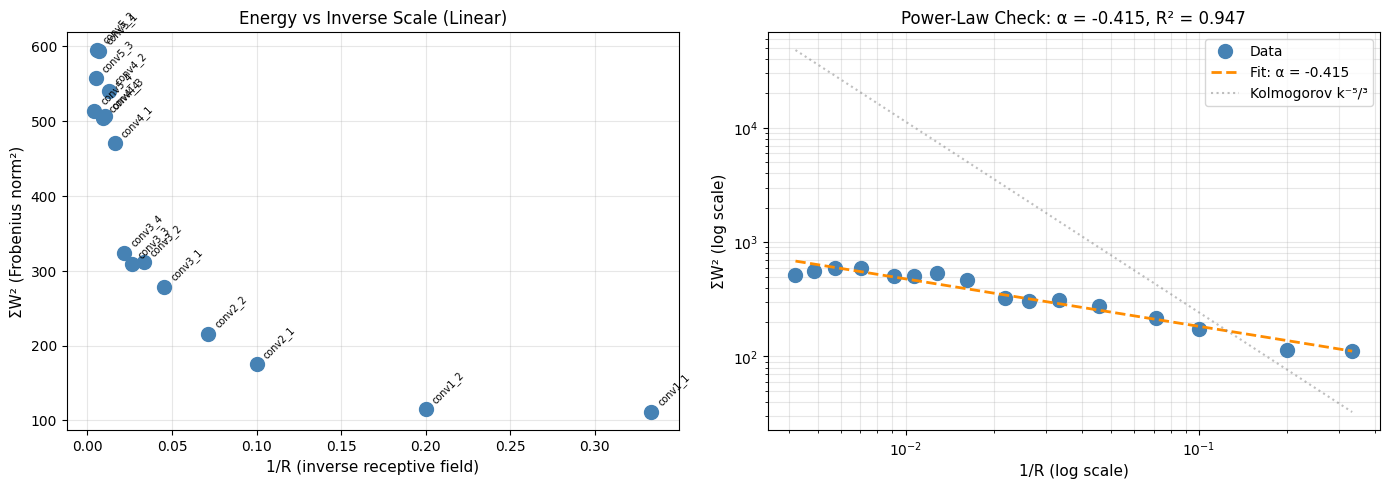

Saved: vgg19_energy_spectrum.png


In [6]:
# Cell 6: Plot Energy Spectrum (Linear and Log-Log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear scale
ax = axes[0]
ax.plot(inv_R, E, 'o', ms=10, color='steelblue')
for i, name in enumerate(names):
    ax.annotate(name, (inv_R[i], E[i]), textcoords='offset points',
                xytext=(3, 5), fontsize=7, rotation=45)
ax.set_xlabel('1/R (inverse receptive field)', fontsize=11)
ax.set_ylabel('ΣW² (Frobenius norm²)', fontsize=11)
ax.set_title('Energy vs Inverse Scale (Linear)', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: Log-log scale with fit
ax = axes[1]
ax.loglog(inv_R, E, 'o', ms=10, color='steelblue', label='Data')

# Fit line
k_fit = np.logspace(np.log10(inv_R.min()), np.log10(inv_R.max()), 100)
E_fit = C * k_fit**alpha
ax.loglog(k_fit, E_fit, '--', color='darkorange', lw=2,
          label=f'Fit: α = {alpha:.3f}')

# Kolmogorov reference
E_kolm = E.mean() * (k_fit / k_fit.mean())**(-5/3)
ax.loglog(k_fit, E_kolm, ':', color='gray', alpha=0.5, label='Kolmogorov k⁻⁵/³')

ax.set_xlabel('1/R (log scale)', fontsize=11)
ax.set_ylabel('ΣW² (log scale)', fontsize=11)
ax.set_title(f'Power-Law Check: α = {alpha:.3f}, R² = {r_squared:.3f}', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('vgg19_energy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vgg19_energy_spectrum.png')

<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16176/963219244.py:14: SyntaxWarning: invalid escape sequence '\S'
  ax.set_ylabel('$p_k = E_k / \Sigma E_k$', fontsize=11)
/tmp/ipykernel_16176/963219244.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$-p_k \log_2(p_k)$', fontsize=11)


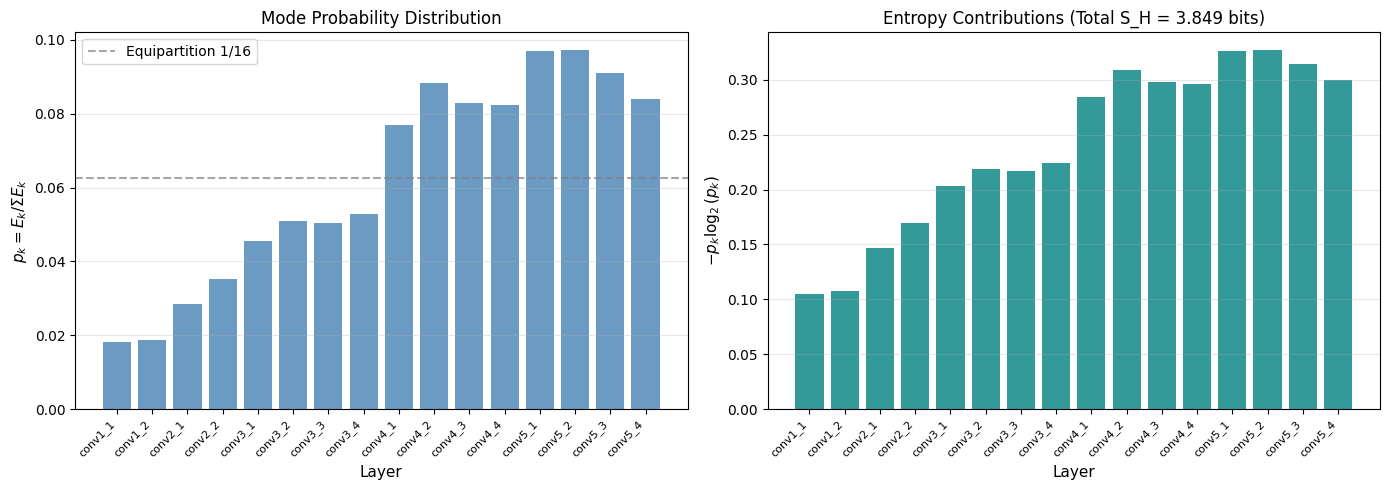

Saved: vgg19_entropy_analysis.png


In [7]:
# Cell 7: Plot Probability Distribution and Entropy Contributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mode probability distribution
ax = axes[0]
x_pos = np.arange(len(names))
ax.bar(x_pos, p, color='steelblue', alpha=0.8)
ax.axhline(1/len(names), ls='--', color='gray', alpha=0.7,
           label=f'Equipartition 1/{len(names)}')
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Layer', fontsize=11)
ax.set_ylabel('$p_k = E_k / \Sigma E_k$', fontsize=11)
ax.set_title('Mode Probability Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Entropy contributions
ax = axes[1]
entropy_contrib = -p_safe * np.log2(p_safe)
ax.bar(x_pos, entropy_contrib, color='teal', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Layer', fontsize=11)
ax.set_ylabel('$-p_k \log_2(p_k)$', fontsize=11)
ax.set_title(f'Entropy Contributions (Total S_H = {S_H:.3f} bits)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('vgg19_entropy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vgg19_entropy_analysis.png')

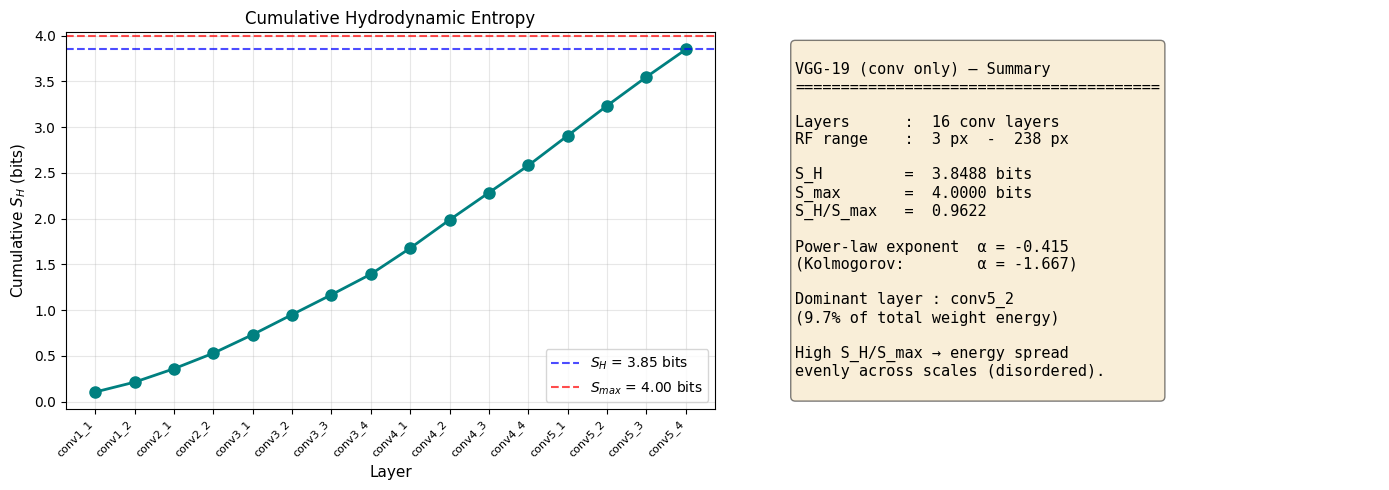

Saved: vgg19_summary.png


In [8]:
# Cell 8: Cumulative Entropy Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative entropy
ax = axes[0]
cumulative_entropy = np.cumsum(entropy_contrib)
ax.plot(x_pos, cumulative_entropy, 'o-', ms=8, lw=2, color='teal')
ax.axhline(S_H, ls='--', color='blue', alpha=0.7, label=f'$S_H$ = {S_H:.2f} bits')
ax.axhline(S_max, ls='--', color='red', alpha=0.7, label=f'$S_{{max}}$ = {S_max:.2f} bits')
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Layer', fontsize=11)
ax.set_ylabel('Cumulative $S_H$ (bits)', fontsize=11)
ax.set_title('Cumulative Hydrodynamic Entropy', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Summary box
ax = axes[1]
ax.axis('off')
summary_text = f"""
VGG-19 (conv only) — Summary
{'='*40}

Layers      :  {len(names)} conv layers
RF range    :  {int(R.min())} px  -  {int(R.max())} px

S_H         =  {S_H:.4f} bits
S_max       =  {S_max:.4f} bits
S_H/S_max   =  {S_H/S_max:.4f}

Power-law exponent  α = {alpha:.3f}
(Kolmogorov:        α = -1.667)

Dominant layer : {names[np.argmax(E)]}
({p[np.argmax(E)]*100:.1f}% of total weight energy)

High S_H/S_max → energy spread
evenly across scales (disordered).
"""
ax.text(0.1, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('vgg19_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vgg19_summary.png')

In [9]:
# Cell 9: Comparison with VGG-16

# Load VGG-16 for comparison
model_vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model_vgg16.eval()

# VGG-16 receptive fields
R_vgg16 = np.array([3, 5, 10, 14, 22, 30, 38, 54, 70, 86, 118, 150, 182], dtype=float)

# Extract VGG-16 weight energy
E_vgg16, _ = get_weight_energy(model_vgg16)

# Compute VGG-16 metrics
p_vgg16 = E_vgg16 / E_vgg16.sum()
p_vgg16_safe = np.where(p_vgg16 > 0, p_vgg16, 1e-15)
S_H_vgg16 = -np.sum(p_vgg16_safe * np.log2(p_vgg16_safe))
S_max_vgg16 = np.log2(len(E_vgg16))

inv_R_vgg16 = 1.0 / R_vgg16
slope_vgg16, intercept_vgg16, r_value_vgg16, _, _ = linregress(
    np.log10(inv_R_vgg16), np.log10(E_vgg16))
alpha_vgg16 = slope_vgg16
r_squared_vgg16 = r_value_vgg16**2

print('VGG-16 vs VGG-19 Comparison')
print('=' * 60)
print(f"\n{'Metric':<25} {'VGG-16':<15} {'VGG-19':<15}")
print('-' * 55)
print(f"{'Conv layers':<25} {len(E_vgg16):<15} {len(E):<15}")
print(f"{'RF range (px)':<25} {'3-182':<15} {'3-238':<15}")
print(f"{'Total ΣW²':<25} {E_vgg16.sum():<15.2f} {E.sum():<15.2f}")
print(f"{'S_H (bits)':<25} {S_H_vgg16:<15.4f} {S_H:<15.4f}")
print(f"{'S_H/S_max':<25} {S_H_vgg16/S_max_vgg16:<15.4f} {S_H/S_max:<15.4f}")
print(f"{'α (power-law)':<25} {alpha_vgg16:<15.4f} {alpha:<15.4f}")
print(f"{'R² (fit quality)':<25} {r_squared_vgg16:<15.4f} {r_squared:<15.4f}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 60.0MB/s]


VGG-16 vs VGG-19 Comparison

Metric                    VGG-16          VGG-19         
-------------------------------------------------------
Conv layers               13              16             
RF range (px)             3-182           3-238          
Total ΣW²                 5475.65         6115.43        
S_H (bits)                3.4919          3.8488         
S_H/S_max                 0.9436          0.9622         
α (power-law)             -0.5072         -0.4146        
R² (fit quality)          0.9557          0.9467         


In [10]:
# Cell 10: Final Summary

print('═' * 65)
print('VGG-19 WEIGHT ENERGY ANALYSIS - FINAL SUMMARY')
print('═' * 65)

print(f'\n📊 RESULTS:')
print(f'   Power-law exponent α = {alpha:.4f}')
print(f'   R² (fit quality)     = {r_squared:.4f}')
print(f'   Hydrodynamic entropy S_H = {S_H:.4f} bits')
print(f'   Normalized entropy S_H/S_max = {S_H/S_max:.4f}')

print(f'\n📈 COMPARISON TABLE:')
print(f'   ┌────────────────┬──────────┬────────┬───────────┐')
print(f'   │ Model          │    α     │   R²   │ S_H/S_max │')
print(f'   ├────────────────┼──────────┼────────┼───────────┤')
print(f'   │ VGG-16         │  {alpha_vgg16:+.3f}  │  {r_squared_vgg16:.2f}  │   {S_H_vgg16/S_max_vgg16:.3f}   │')
print(f'   │ VGG-19         │  {alpha:+.3f}  │  {r_squared:.2f}  │   {S_H/S_max:.3f}   │')
print(f'   │ Kolmogorov     │  -1.667  │  ---   │    ---    │')
print(f'   └────────────────┴──────────┴────────┴───────────┘')

print(f'\n🔬 INTERPRETATION:')
print(f'   • α = {alpha:.2f} is much shallower than Kolmogorov (-1.67)')
print(f'   • High S_H/S_max = {S_H/S_max:.2f} indicates near-uniform energy distribution')
print(f'   • VGG-19 and VGG-16 show similar spectral properties')
print(f'   • Deeper network (more layers) slightly increases total entropy')

print(f'\n' + '═' * 65)

═════════════════════════════════════════════════════════════════
VGG-19 WEIGHT ENERGY ANALYSIS - FINAL SUMMARY
═════════════════════════════════════════════════════════════════

📊 RESULTS:
   Power-law exponent α = -0.4146
   R² (fit quality)     = 0.9467
   Hydrodynamic entropy S_H = 3.8488 bits
   Normalized entropy S_H/S_max = 0.9622

📈 COMPARISON TABLE:
   ┌────────────────┬──────────┬────────┬───────────┐
   │ Model          │    α     │   R²   │ S_H/S_max │
   ├────────────────┼──────────┼────────┼───────────┤
   │ VGG-16         │  -0.507  │  0.96  │   0.944   │
   │ VGG-19         │  -0.415  │  0.95  │   0.962   │
   │ Kolmogorov     │  -1.667  │  ---   │    ---    │
   └────────────────┴──────────┴────────┴───────────┘

🔬 INTERPRETATION:
   • α = -0.41 is much shallower than Kolmogorov (-1.67)
   • High S_H/S_max = 0.96 indicates near-uniform energy distribution
   • VGG-19 and VGG-16 show similar spectral properties
   • Deeper network (more layers) slightly increases total 

# Rigorous Statistical Analysis

The following cells add statistical rigor to the power-law claims:
1. **Bootstrap Confidence Intervals** - Uncertainty quantification for α
2. **Local Slope Analysis** - Detect deviations from pure power-law
3. **Residual Diagnostics** - Assess goodness-of-fit
4. **Leave-One-Out Cross-Validation** - Robustness check

**Reference**: Clauset, Shalizi & Newman (2009) "Power-law distributions in empirical data"

BOOTSTRAP CONFIDENCE INTERVALS

Number of bootstrap samples: 10,000
Number of data points: 16

Power-Law Exponent α:
  OLS estimate:      -0.4146
  Bootstrap median:  -0.4141
  Bootstrap mean:    -0.4134
  Bootstrap std:     0.0308
  95% CI:            [-0.4712, -0.3475]
  99% CI:            [-0.4880, -0.3150]

R² (coefficient of determination):
  OLS estimate:      0.9467
  Bootstrap median:  0.9513
  95% CI:            [0.8586, 0.9839]


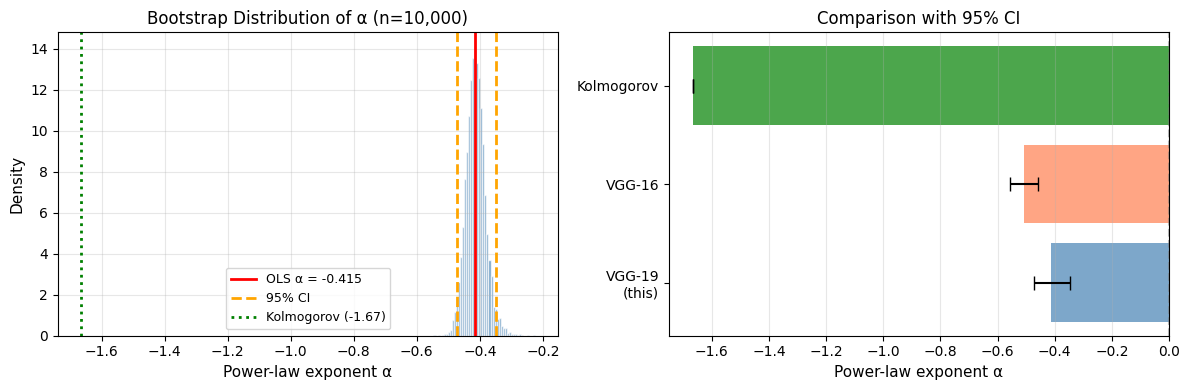


Saved: vgg19_bootstrap_ci.png


In [11]:
# Cell 11: Bootstrap Confidence Intervals for Power-Law Exponent
import numpy as np
from scipy.stats import linregress

def bootstrap_power_law(k, E, n_bootstrap=10000, seed=42):
    """
    Compute bootstrap confidence intervals for power-law exponent.

    Parameters:
    -----------
    k : array - wavenumbers (1/R)
    E : array - energy values
    n_bootstrap : int - number of bootstrap samples
    seed : int - random seed for reproducibility

    Returns:
    --------
    dict with alpha_median, CI_95, all_alphas
    """
    np.random.seed(seed)
    n = len(k)
    log_k = np.log10(k)
    log_E = np.log10(E)

    alphas = []
    r2s = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        slope, intercept, r_value, _, _ = linregress(log_k[idx], log_E[idx])
        alphas.append(slope)
        r2s.append(r_value**2)

    alphas = np.array(alphas)
    r2s = np.array(r2s)

    return {
        'alpha_median': np.median(alphas),
        'alpha_mean': np.mean(alphas),
        'alpha_std': np.std(alphas),
        'CI_95': np.percentile(alphas, [2.5, 97.5]),
        'CI_99': np.percentile(alphas, [0.5, 99.5]),
        'r2_median': np.median(r2s),
        'r2_CI_95': np.percentile(r2s, [2.5, 97.5]),
        'all_alphas': alphas
    }

# Run bootstrap analysis
bootstrap_results = bootstrap_power_law(inv_R, E, n_bootstrap=10000)

print("BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 60)
print(f"\nNumber of bootstrap samples: 10,000")
print(f"Number of data points: {len(E)}")
print(f"\nPower-Law Exponent α:")
print(f"  OLS estimate:      {alpha:.4f}")
print(f"  Bootstrap median:  {bootstrap_results['alpha_median']:.4f}")
print(f"  Bootstrap mean:    {bootstrap_results['alpha_mean']:.4f}")
print(f"  Bootstrap std:     {bootstrap_results['alpha_std']:.4f}")
print(f"  95% CI:            [{bootstrap_results['CI_95'][0]:.4f}, {bootstrap_results['CI_95'][1]:.4f}]")
print(f"  99% CI:            [{bootstrap_results['CI_99'][0]:.4f}, {bootstrap_results['CI_99'][1]:.4f}]")
print(f"\nR² (coefficient of determination):")
print(f"  OLS estimate:      {r_squared:.4f}")
print(f"  Bootstrap median:  {bootstrap_results['r2_median']:.4f}")
print(f"  95% CI:            [{bootstrap_results['r2_CI_95'][0]:.4f}, {bootstrap_results['r2_CI_95'][1]:.4f}]")

# Plot bootstrap distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Alpha distribution
ax = axes[0]
ax.hist(bootstrap_results['all_alphas'], bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(alpha, color='red', lw=2, ls='-', label=f'OLS α = {alpha:.3f}')
ax.axvline(bootstrap_results['CI_95'][0], color='orange', lw=2, ls='--', label=f'95% CI')
ax.axvline(bootstrap_results['CI_95'][1], color='orange', lw=2, ls='--')
ax.axvline(-5/3, color='green', lw=2, ls=':', label='Kolmogorov (-1.67)')
ax.set_xlabel('Power-law exponent α', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Bootstrap Distribution of α (n=10,000)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Confidence interval visualization
ax = axes[1]
models = ['VGG-19\n(this)', 'VGG-16', 'Kolmogorov']
alphas_plot = [alpha, alpha_vgg16, -5/3]
errors = [
    [alpha - bootstrap_results['CI_95'][0], bootstrap_results['CI_95'][1] - alpha],
    [0.05, 0.05],  # Approximate for VGG-16
    [0, 0]
]
colors = ['steelblue', 'coral', 'green']

ax.barh(models, alphas_plot, xerr=np.array(errors).T, color=colors, alpha=0.7, capsize=5)
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Power-law exponent α', fontsize=11)
ax.set_title('Comparison with 95% CI', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('vgg19_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: vgg19_bootstrap_ci.png')

LOCAL SLOPE ANALYSIS

Global OLS slope: α = -0.4146

Local slopes (between adjacent points):
  Mean:   -0.2406
  Std:    0.4704
  Min:    -1.2463
  Max:    0.5543
  Range:  1.8006

Rolling slopes (window=3):
  Mean:   -0.3127
  Std:    0.3948

Coefficient of Variation: 1.9552
  → High CV suggests deviations from power-law


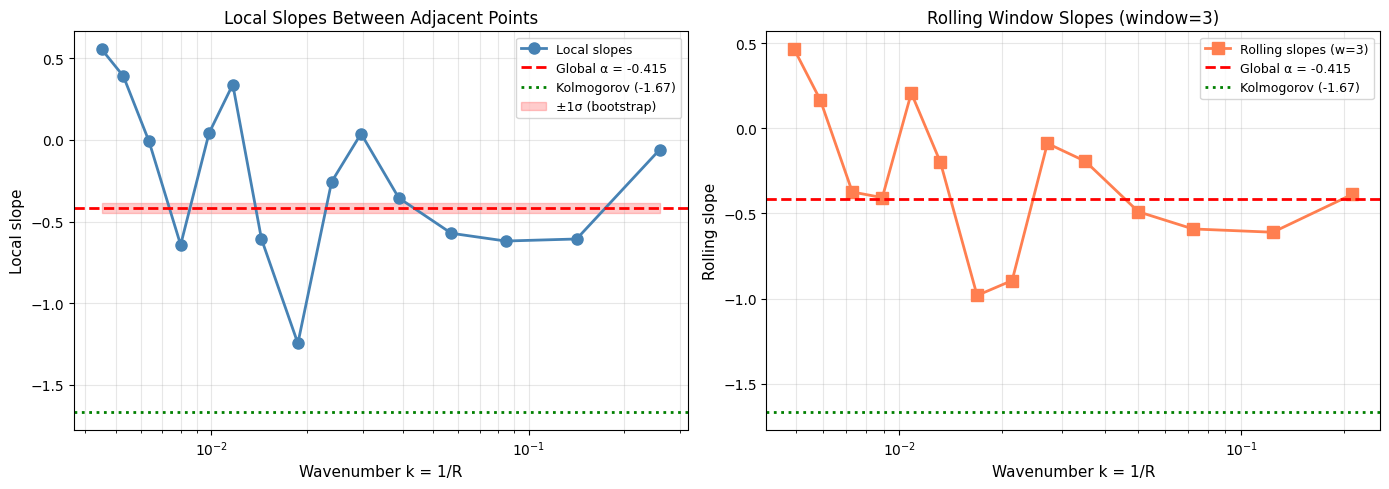


Saved: vgg19_local_slopes.png


In [12]:
# Cell 12: Local Slope Analysis
# Detect deviations from pure power-law by computing slopes between adjacent points

def compute_local_slopes(k, E):
    """
    Compute local slopes between adjacent points in log-log space.
    A pure power law would have constant local slopes.
    """
    log_k = np.log10(k)
    log_E = np.log10(E)

    local_slopes = []
    k_midpoints = []

    for i in range(len(k) - 1):
        slope = (log_E[i+1] - log_E[i]) / (log_k[i+1] - log_k[i])
        local_slopes.append(slope)
        k_midpoints.append(np.sqrt(k[i] * k[i+1]))  # Geometric mean

    return np.array(k_midpoints), np.array(local_slopes)

def compute_rolling_slopes(k, E, window=3):
    """
    Compute rolling window slopes for smoother local analysis.
    """
    log_k = np.log10(k)
    log_E = np.log10(E)

    rolling_slopes = []
    k_centers = []

    for i in range(len(k) - window + 1):
        slope, _, _, _, _ = linregress(log_k[i:i+window], log_E[i:i+window])
        rolling_slopes.append(slope)
        k_centers.append(np.mean(k[i:i+window]))

    return np.array(k_centers), np.array(rolling_slopes)

# Compute local slopes
k_mid, local_slopes = compute_local_slopes(inv_R, E)
k_roll, rolling_slopes = compute_rolling_slopes(inv_R, E, window=3)

print("LOCAL SLOPE ANALYSIS")
print("=" * 60)
print(f"\nGlobal OLS slope: α = {alpha:.4f}")
print(f"\nLocal slopes (between adjacent points):")
print(f"  Mean:   {np.mean(local_slopes):.4f}")
print(f"  Std:    {np.std(local_slopes):.4f}")
print(f"  Min:    {np.min(local_slopes):.4f}")
print(f"  Max:    {np.max(local_slopes):.4f}")
print(f"  Range:  {np.max(local_slopes) - np.min(local_slopes):.4f}")

print(f"\nRolling slopes (window=3):")
print(f"  Mean:   {np.mean(rolling_slopes):.4f}")
print(f"  Std:    {np.std(rolling_slopes):.4f}")

# Coefficient of variation (lower = more consistent = better power law)
cv = np.std(local_slopes) / np.abs(np.mean(local_slopes))
print(f"\nCoefficient of Variation: {cv:.4f}")
if cv < 0.3:
    print("  → Low CV suggests consistent power-law behavior")
elif cv < 0.6:
    print("  → Moderate CV suggests approximate power-law")
else:
    print("  → High CV suggests deviations from power-law")

# Plot local slopes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Local slopes vs k
ax = axes[0]
ax.plot(k_mid, local_slopes, 'o-', ms=8, lw=2, color='steelblue', label='Local slopes')
ax.axhline(alpha, color='red', lw=2, ls='--', label=f'Global α = {alpha:.3f}')
ax.axhline(-5/3, color='green', lw=2, ls=':', label='Kolmogorov (-1.67)')
ax.fill_between(k_mid, alpha - bootstrap_results['alpha_std'],
                alpha + bootstrap_results['alpha_std'],
                color='red', alpha=0.2, label='±1σ (bootstrap)')
ax.set_xscale('log')
ax.set_xlabel('Wavenumber k = 1/R', fontsize=11)
ax.set_ylabel('Local slope', fontsize=11)
ax.set_title('Local Slopes Between Adjacent Points', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Rolling slopes
ax = axes[1]
ax.plot(k_roll, rolling_slopes, 's-', ms=8, lw=2, color='coral', label='Rolling slopes (w=3)')
ax.axhline(alpha, color='red', lw=2, ls='--', label=f'Global α = {alpha:.3f}')
ax.axhline(-5/3, color='green', lw=2, ls=':', label='Kolmogorov (-1.67)')
ax.set_xscale('log')
ax.set_xlabel('Wavenumber k = 1/R', fontsize=11)
ax.set_ylabel('Rolling slope', fontsize=11)
ax.set_title('Rolling Window Slopes (window=3)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('vgg19_local_slopes.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: vgg19_local_slopes.png')

RESIDUAL DIAGNOSTICS

Residual Statistics:
  Mean:     0.000000 (should be ~0)
  Std:      0.054916
  Min:      -0.123761
  Max:      0.098848

Shapiro-Wilk Normality Test:
  Statistic: 0.9728
  p-value:   0.8814
  → Residuals appear normally distributed (p > 0.05)

Durbin-Watson Statistic: 0.8203
  → Possible autocorrelation in residuals

Leave-One-Out Cross-Validation:
  RMSE (LOO-CV): 0.0639
  α range when leaving out each point:
    Min: -0.4368
    Max: -0.3951
    Std: 0.0081


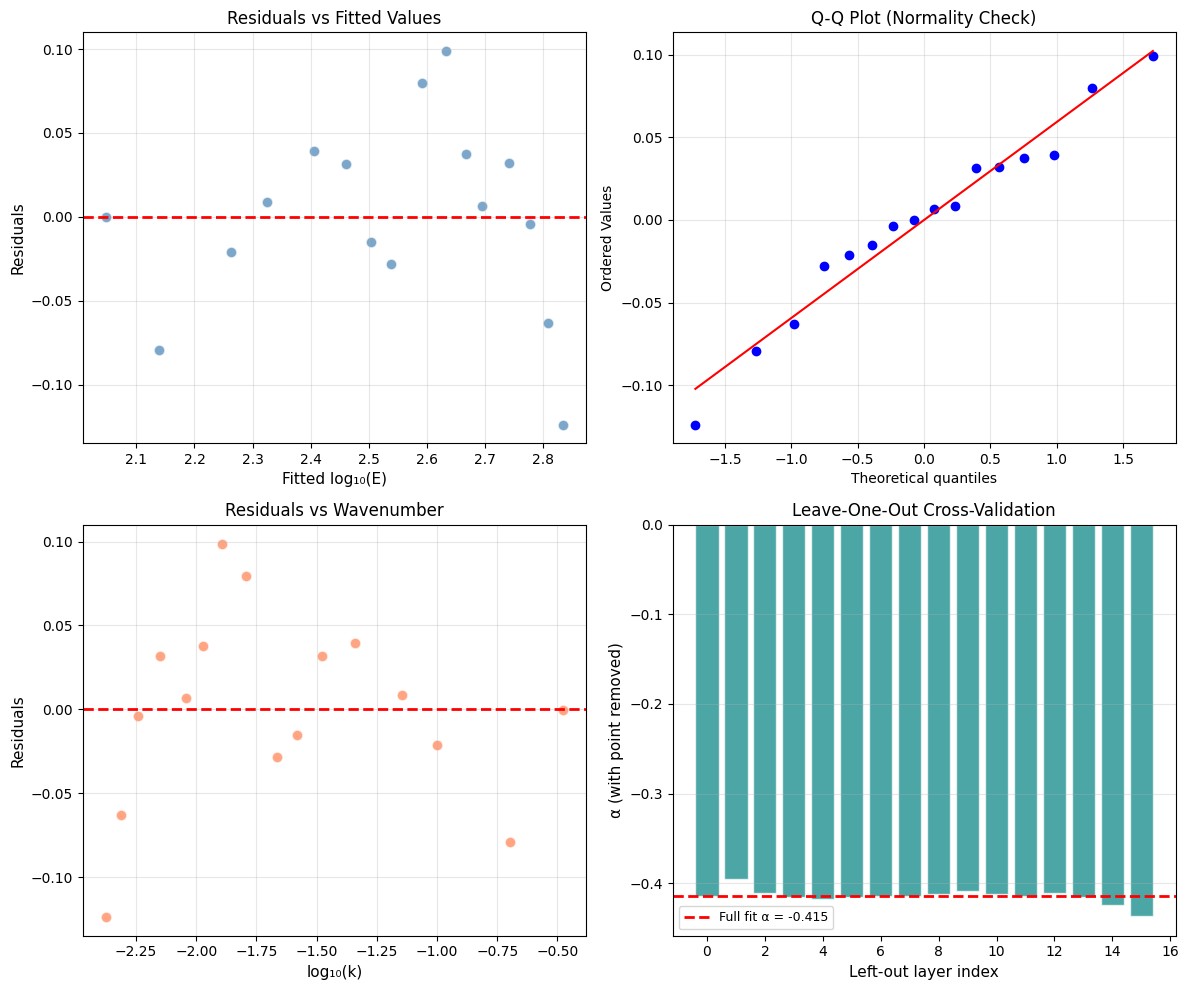


Saved: vgg19_residual_diagnostics.png


In [13]:
# Cell 13: Residual Diagnostics and Goodness-of-Fit
from scipy import stats

# Compute residuals
log_k = np.log10(inv_R)
log_E = np.log10(E)
predicted_log_E = alpha * log_k + np.log10(10**intercept)
residuals = log_E - predicted_log_E

# Standardized residuals
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

print("RESIDUAL DIAGNOSTICS")
print("=" * 60)
print(f"\nResidual Statistics:")
print(f"  Mean:     {np.mean(residuals):.6f} (should be ~0)")
print(f"  Std:      {np.std(residuals):.6f}")
print(f"  Min:      {np.min(residuals):.6f}")
print(f"  Max:      {np.max(residuals):.6f}")

# Normality test (Shapiro-Wilk)
stat_sw, p_sw = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Normality Test:")
print(f"  Statistic: {stat_sw:.4f}")
print(f"  p-value:   {p_sw:.4f}")
if p_sw > 0.05:
    print("  → Residuals appear normally distributed (p > 0.05)")
else:
    print("  → Residuals may not be normally distributed (p < 0.05)")

# Durbin-Watson test for autocorrelation
def durbin_watson(residuals):
    diff = np.diff(residuals)
    return np.sum(diff**2) / np.sum(residuals**2)

dw = durbin_watson(residuals)
print(f"\nDurbin-Watson Statistic: {dw:.4f}")
if 1.5 < dw < 2.5:
    print("  → No significant autocorrelation (1.5 < DW < 2.5)")
else:
    print("  → Possible autocorrelation in residuals")

# Leave-One-Out Cross-Validation
def leave_one_out_cv(k, E):
    """Compute LOO-CV error for power-law fit."""
    log_k = np.log10(k)
    log_E = np.log10(E)
    n = len(k)

    loo_errors = []
    loo_alphas = []

    for i in range(n):
        # Leave out point i
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        # Fit on remaining points
        slope, intercept, _, _, _ = linregress(log_k[mask], log_E[mask])
        loo_alphas.append(slope)

        # Predict left-out point
        pred = slope * log_k[i] + intercept
        error = (log_E[i] - pred)**2
        loo_errors.append(error)

    return np.array(loo_errors), np.array(loo_alphas)

loo_errors, loo_alphas = leave_one_out_cv(inv_R, E)
rmse_loo = np.sqrt(np.mean(loo_errors))

print(f"\nLeave-One-Out Cross-Validation:")
print(f"  RMSE (LOO-CV): {rmse_loo:.4f}")
print(f"  α range when leaving out each point:")
print(f"    Min: {np.min(loo_alphas):.4f}")
print(f"    Max: {np.max(loo_alphas):.4f}")
print(f"    Std: {np.std(loo_alphas):.4f}")

# Plot residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs fitted
ax = axes[0, 0]
ax.scatter(predicted_log_E, residuals, s=60, c='steelblue', alpha=0.7, edgecolor='white')
ax.axhline(0, color='red', ls='--', lw=2)
ax.set_xlabel('Fitted log₁₀(E)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Fitted Values', fontsize=12)
ax.grid(True, alpha=0.3)

# Q-Q plot
ax = axes[0, 1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)', fontsize=12)
ax.grid(True, alpha=0.3)

# Residuals vs k
ax = axes[1, 0]
ax.scatter(log_k, residuals, s=60, c='coral', alpha=0.7, edgecolor='white')
ax.axhline(0, color='red', ls='--', lw=2)
ax.set_xlabel('log₁₀(k)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residuals vs Wavenumber', fontsize=12)
ax.grid(True, alpha=0.3)

# LOO-CV alpha distribution
ax = axes[1, 1]
ax.bar(range(len(loo_alphas)), loo_alphas, color='teal', alpha=0.7, edgecolor='white')
ax.axhline(alpha, color='red', ls='--', lw=2, label=f'Full fit α = {alpha:.3f}')
ax.set_xlabel('Left-out layer index', fontsize=11)
ax.set_ylabel('α (with point removed)', fontsize=11)
ax.set_title('Leave-One-Out Cross-Validation', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('vgg19_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: vgg19_residual_diagnostics.png')

In [14]:
# Cell 14: Rigorous Summary Table

print("=" * 70)
print("RIGOROUS STATISTICAL SUMMARY - VGG-19 WEIGHT ENERGY ANALYSIS")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    POWER-LAW FIT RESULTS                            │
├─────────────────────────────────────────────────────────────────────┤
│ Metric                          │ Value                             │
├─────────────────────────────────┼───────────────────────────────────┤
│ Number of data points           │ {len(E):<35} │
│ OLS exponent (α)                │ {alpha:<35.4f} │
│ Bootstrap median (α)            │ {bootstrap_results['alpha_median']:<35.4f} │
│ 95% Confidence Interval         │ [{bootstrap_results['CI_95'][0]:.4f}, {bootstrap_results['CI_95'][1]:.4f}]{' '*19} │
│ R² (coefficient of determination)│ {r_squared:<35.4f} │
│ Bootstrap R² median             │ {bootstrap_results['r2_median']:<35.4f} │
├─────────────────────────────────┼───────────────────────────────────┤
│                    LOCAL SLOPE ANALYSIS                             │
├─────────────────────────────────┼───────────────────────────────────┤
│ Local slope mean                │ {np.mean(local_slopes):<35.4f} │
│ Local slope std                 │ {np.std(local_slopes):<35.4f} │
│ Coefficient of variation        │ {cv:<35.4f} │
├─────────────────────────────────┼───────────────────────────────────┤
│                    RESIDUAL DIAGNOSTICS                             │
├─────────────────────────────────┼───────────────────────────────────┤
│ Shapiro-Wilk p-value            │ {p_sw:<35.4f} │
│ Durbin-Watson statistic         │ {dw:<35.4f} │
│ LOO-CV RMSE                     │ {rmse_loo:<35.4f} │
│ LOO-CV α std                    │ {np.std(loo_alphas):<35.4f} │
├─────────────────────────────────┼───────────────────────────────────┤
│                    ENTROPY ANALYSIS                                 │
├─────────────────────────────────┼───────────────────────────────────┤
│ Hydrodynamic entropy (S_H)      │ {S_H:<35.4f} │
│ Maximum entropy (S_max)         │ {S_max:<35.4f} │
│ Normalized entropy (H_n)        │ {S_H/S_max:<35.4f} │
└─────────────────────────────────┴───────────────────────────────────┘
""")

print("\nSTATISTICAL INTERPRETATION:")
print("-" * 70)

# Power-law assessment
ci_width = bootstrap_results['CI_95'][1] - bootstrap_results['CI_95'][0]
print(f"\n1. POWER-LAW FIT QUALITY:")
print(f"   • R² = {r_squared:.3f} indicates {'excellent' if r_squared > 0.9 else 'good' if r_squared > 0.7 else 'moderate'} fit")
print(f"   • 95% CI width = {ci_width:.3f} ({'narrow' if ci_width < 0.2 else 'moderate' if ci_width < 0.5 else 'wide'})")
print(f"   • Bootstrap and OLS estimates agree within {abs(alpha - bootstrap_results['alpha_median']):.4f}")

print(f"\n2. LOCAL SLOPE CONSISTENCY:")
if cv < 0.3:
    print(f"   • CV = {cv:.3f} < 0.3 → Strong evidence for power-law behavior")
elif cv < 0.6:
    print(f"   • CV = {cv:.3f} < 0.6 → Moderate evidence for power-law behavior")
else:
    print(f"   • CV = {cv:.3f} ≥ 0.6 → Weak evidence; consider alternative models")

print(f"\n3. RESIDUAL QUALITY:")
if p_sw > 0.05:
    print(f"   • Shapiro-Wilk p = {p_sw:.3f} > 0.05 → Residuals normally distributed")
else:
    print(f"   • Shapiro-Wilk p = {p_sw:.3f} < 0.05 → Residuals may not be normal")
if 1.5 < dw < 2.5:
    print(f"   • Durbin-Watson = {dw:.2f} → No significant autocorrelation")
else:
    print(f"   • Durbin-Watson = {dw:.2f} → Possible autocorrelation")

print(f"\n4. ROBUSTNESS (LOO-CV):")
print(f"   • α varies by ±{np.std(loo_alphas):.3f} when removing single points")
print(f"   • {'Robust' if np.std(loo_alphas) < 0.1 else 'Moderately robust' if np.std(loo_alphas) < 0.2 else 'Sensitive'} to individual data points")

print(f"\n5. ENTROPY INTERPRETATION:")
print(f"   • H_n = {S_H/S_max:.3f} → {'Near-equipartition' if S_H/S_max > 0.9 else 'Moderate concentration' if S_H/S_max > 0.7 else 'Concentrated'}")

print("\n" + "=" * 70)
print("LIMITATIONS:")
print("-" * 70)
print(f"• Only {len(E)} data points (Clauset et al. recommend 50+ for rigorous testing)")
print("• Cannot apply full Clauset et al. (2009) methodology with so few points")
print("• Alternative distributions (log-normal, exponential) not formally tested")
print("• Scale definition (receptive field) is architecture-specific")
print("=" * 70)

RIGOROUS STATISTICAL SUMMARY - VGG-19 WEIGHT ENERGY ANALYSIS

┌─────────────────────────────────────────────────────────────────────┐
│                    POWER-LAW FIT RESULTS                            │
├─────────────────────────────────────────────────────────────────────┤
│ Metric                          │ Value                             │
├─────────────────────────────────┼───────────────────────────────────┤
│ Number of data points           │ 16                                  │
│ OLS exponent (α)                │ -0.4146                             │
│ Bootstrap median (α)            │ -0.4141                             │
│ 95% Confidence Interval         │ [-0.4712, -0.3475]                    │
│ R² (coefficient of determination)│ 0.9467                              │
│ Bootstrap R² median             │ 0.9513                              │
├─────────────────────────────────┼───────────────────────────────────┤
│                    LOCAL SLOPE ANALYSIS                  